In [232]:
%matplotlib inline   
# For VS code use above line
# For jupyter notbook use "%matplotlib ipympl"

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backends is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


In [221]:
from lasy.profiles.gaussian_profile import GaussianProfile
from lasy.profiles.longitudinal import LongitudinalProfileFromData
from lasy.profiles.transverse import TransverseProfileFromData
from lasy.profiles.combined_profile import CombinedLongitudinalTransverseProfile
from lasy.laser import Laser

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import scipy

In [222]:
wavelength     = 815e-9  # Laser wavelength in meters
polarization   = (1, 0)  # Linearly polarized in the x direction
energy_J       = 24      # Pulse energy in Joules

# Measured Profile (20-24J)

## Longitudinal (Time)

In [234]:
#df_intensity = pd.read_csv("FROG_analysis_2023-06-15/23_0615Scan007Frog-HPD-1Et.txt", delimiter="\t")
dataFile = '2017_05_17T12_00_36_460.mat'
df_intensity= scipy.io.loadmat(dataFile)

#display(df_intensity)

compressor_setting_mm = 10.8
column_Re = f"Re({compressor_setting_mm}mm)"
column_Im = f"Im({compressor_setting_mm}mm)"

# time
fs = 1e-15
time_s = df_intensity['analysis']['t'][0][0][0] * fs

# E_complex(t)
Et_Re = df_intensity['analysis']['E_t']
Et_Im = df_intensity['analysis']['E_w']
Et_Re = Et_Re[0][0]
Et_Im = Et_Im[0][0]
Et_complex = Et_Re + 1j * Et_Im
#print(Et_complex, Et_complex.dtype)
# retrieve Intensity and Phase
Et_intensity = np.abs(Et_complex)**2
#print(Et_intensity)
Et_phase = np.arctan(Et_Im, Et_Re)

# shift to peak intensity at t=0

peak_index = np.argmax(Et_intensity)
time_s -= time_s[peak_index]

print(time_s, Et_phase.shape, Et_phase.dtype)

[-3.86386260e-13 -3.79724428e-13 -3.73062595e-13 -3.66400763e-13
 -3.59738931e-13 -3.53077099e-13 -3.46415267e-13 -3.39753435e-13
 -3.33091603e-13 -3.26429771e-13 -3.19767939e-13 -3.13106107e-13
 -3.06444275e-13 -2.99782443e-13 -2.93120611e-13 -2.86458779e-13
 -2.79796947e-13 -2.73135115e-13 -2.66473282e-13 -2.59811450e-13
 -2.53149618e-13 -2.46487786e-13 -2.39825954e-13 -2.33164122e-13
 -2.26502290e-13 -2.19840458e-13 -2.13178626e-13 -2.06516794e-13
 -1.99854962e-13 -1.93193130e-13 -1.86531298e-13 -1.79869466e-13
 -1.73207634e-13 -1.66545802e-13 -1.59883969e-13 -1.53222137e-13
 -1.46560305e-13 -1.39898473e-13 -1.33236641e-13 -1.26574809e-13
 -1.19912977e-13 -1.13251145e-13 -1.06589313e-13 -9.99274809e-14
 -9.32656489e-14 -8.66038168e-14 -7.99419847e-14 -7.32801527e-14
 -6.66183206e-14 -5.99564886e-14 -5.32946565e-14 -4.66328244e-14
 -3.99709924e-14 -3.33091603e-14 -2.66473282e-14 -1.99854962e-14
 -1.33236641e-14 -6.66183206e-15  0.00000000e+00  6.66183206e-15
  1.33236641e-14  1.99854

In [235]:
fs = 1e-15
longitudinal_data = {
    "datatype": "temporal",
    "axis": time_s.flatten(),
    "intensity": Et_intensity.flatten(),
    "phase": Et_phase.flatten(),
    "wavelength": wavelength
}

longitudinal_profile = LongitudinalProfileFromData(
    longitudinal_data,
    lo=-200 * fs,
    hi=200 * fs
)


In [236]:
longitudinal_profile.evaluate(time_s)

array([0.08446769+4.33011541e-04j, 0.08446769+4.33011541e-04j,
       0.08446769+4.33011541e-04j, 0.08446769+4.33011541e-04j,
       0.08446769+4.33011541e-04j, 0.08446769+4.33011541e-04j,
       0.08446769+4.33011541e-04j, 0.08446769+4.33011541e-04j,
       0.08446769+4.33011541e-04j, 0.08446769+4.33011541e-04j,
       0.08446769+4.33011541e-04j, 0.08446769+4.33011541e-04j,
       0.08446769+4.33011541e-04j, 0.08446769+4.33011541e-04j,
       0.08446769+4.33011541e-04j, 0.08446769+4.33011541e-04j,
       0.08446769+4.33011541e-04j, 0.08446769+4.33011541e-04j,
       0.08446769+4.33011541e-04j, 0.08446769+4.33011541e-04j,
       0.08446769+4.33011541e-04j, 0.08446769+4.33011541e-04j,
       0.08446769+4.33011541e-04j, 0.08446769+4.33011541e-04j,
       0.08446769+4.33011541e-04j, 0.08446769+4.33011541e-04j,
       0.08446769+4.33011541e-04j, 0.08446769+4.33011541e-04j,
       0.08446769+4.33011541e-04j, 0.38178627+1.45486571e-01j,
       0.29909257+4.74199418e-02j, 0.13810396+1.8965066

## Transverse Mode

In [226]:
%conda install -c conda-forge -y scikit-image

/opt/anaconda3/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=75837) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


Retrieving notices: ...working... done
Channels:
 - conda-forge
 - defaults
Platform: osx-64
Solving environment: done

## Package Plan ##

  environment location: /opt/anaconda3

  added / updated specs:
    - scikit-image


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    openssl-3.3.1              |       hd23fc13_3         2.4 MB  conda-forge
    ------------------------------------------------------------
                                           Total:         2.4 MB

The following packages will be UPDATED:

  openssl                                  3.3.1-h87427d6_2 --> 3.3.1-hd23fc13_3 

The following packages will be SUPERSEDED by a higher-priority channel:

  certifi            pkgs/main/osx-64::certifi-2024.7.4-py~ --> conda-forge/noarch::certifi-2024.7.4-pyhd8ed1ab_0 
  conda              pkgs/main::conda-24.7.1-py312hecd8cb5~ --> conda-forge::conda-24.7.1-py312hb401068_0 




In [237]:
import skimage

# Define the transverse profile of the laser pulse
#img_url = "https://user-images.githubusercontent.com/27694869/228038930-d6ab03b1-a726-4b41-a378-5f4a83dc3778.png"
#intensityData = skimage.io.imread(img_url)
img= "/Users/patilpar/Desktop/output.png"
intensityData = skimage.io.imread(img)
#print(intensityData)
# data cleaning: remove negative values
intensityData[intensityData < 2.1] = 0
# data cleaning: normalize values
pixel_calib = 0.186e-6
lo = (
    -intensityData.shape[0] / 2 * pixel_calib,
    -intensityData.shape[1] / 2 * pixel_calib,
)
hi = (
    intensityData.shape[0] / 2 * pixel_calib,
    intensityData.shape[1] / 2 * pixel_calib,
)
print(lo, hi)
print(intensityData.shape)
# data cleaning: zoom/clip (if needed)

(-3.4317e-05, -4.5756e-05) (3.4317e-05, 4.5756e-05)
(369, 492, 4)


In [238]:

cal = 0.143 # spatial calibration mode imager
# zoom/clip
# x_i_clip = [100, -100]#
# y_i_clip = [100, -100]#

#transverse_data = np.loadtxt("/Users/patilpar/Desktop/LASY/docs/source/tutorials/2024_08_06_28mLaserData.mat", delimiter=",")
# Read in the data file
dataFile = '2024_08_06_28mLaserData.mat'
data = scipy.io.loadmat(dataFile)
transverse_data = data['MP2NF'][0][0][0].astype(float)

# data cleaning: remove negative values
transverse_scale = np.max(transverse_data)
transverse_data[transverse_data<transverse_scale/100] = 0 # remove negative values, and the upper limit is user defined.[Recommended: 10% of the maximum value]
# data cleaning: normalize
         


# transverse_data /= transverse_scale
# data cleaning: zoom/clip
# Here we haev the problem that the resulting data is not a square matrix, which is required for the transverse profile,
# so we need to clip the data to a square matrix
# x_i_clip = [100, -100]
# y = (transverse_data.shape[1]-transverse_data.shape[0]+x_i_clip[0]-x_i_clip[1])/2
# y = int(y)
# y_i_clip = [y, -y]

# transverse_data = transverse_data[
#     x_i_clip[0]:x_i_clip[1],
#     y_i_clip[0]:y_i_clip[1]
# ]
print(transverse_data.shape)
x_i_clip = [150, -150]   #####previous values
y_i_clip = [150, -150]
transverse_data = transverse_data[
    x_i_clip[0]:x_i_clip[1],
    y_i_clip[0]:y_i_clip[1]
]

# axes
transverse_x_mu = cal * np.arange(0, transverse_data.shape[1], 70)
transverse_y_mu = cal * np.arange(0, transverse_data.shape[0], 70)
transverse_y_mu
print(transverse_data[350][759])#
print(len(transverse_data))#
##print(transverse_x_mu)#
##print(transverse_y_mu)#

(960, 1280)
0.0
660


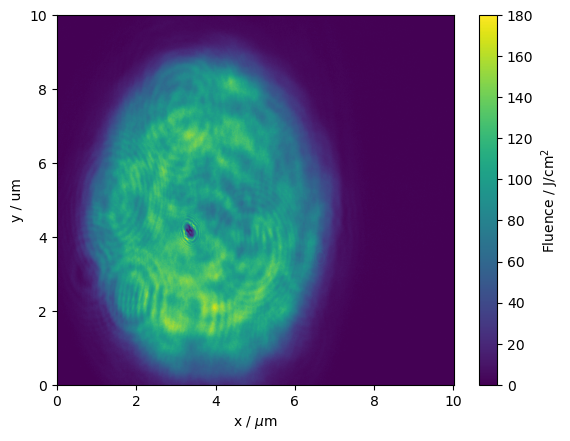

In [239]:
fig,ax = plt.subplots()
cax = ax.imshow(
    transverse_data,
    aspect="auto",
    extent=[
        transverse_x_mu[0], transverse_x_mu[1],
        transverse_y_mu[0], transverse_y_mu[1]
    ],
    #norm=LogNorm(),
)
# Add a colorbar
color_bar = fig.colorbar(cax)
# Add a label to the colorbar
color_bar.set_label(r"Fluence / J/cm$^2$")
ax.set_xlabel(r"x / $\mu$m")
ax.set_ylabel("y / um")

# Set the tick positions
#ax.set_xticks(transverse_x_mu)
#ax.set_yticks(transverse_y_mu)

# Set the tick labels
#ax.set_xticklabels([f"{i:.{0}f}" for i in transverse_x_mu])
#ax.set_yticklabels([f"{j:.{0}f}" for j in transverse_y_mu])

plt.show()

In [240]:
mu = 1e-6
transverse_profile = TransverseProfileFromData(
    transverse_data,
    [transverse_x_mu[0]  * mu, transverse_y_mu[0]  * mu],
    [transverse_x_mu[1] * mu, transverse_y_mu[1] * mu]
)
print([transverse_x_mu[0]  * mu, transverse_y_mu[0]  * mu],
    [transverse_x_mu[1] * mu, transverse_y_mu[1] * mu])#

[0.0, 0.0] [1.0009999999999999e-05, 1.0009999999999999e-05]


# Transversal Profile Denoising
See https://github.com/LASY-org/lasy/blob/13f0e4515493deca36c1375be1d9e83c7e379d42/examples/example_modal_decomposition_data.py

In [241]:
from lasy.utils.mode_decomposition import hermite_gauss_decomposition
from lasy.profiles.transverse.hermite_gaussian_profile import (
    HermiteGaussianTransverseProfile,
)
print(transverse_profile)
# Calculate the decomposition into hermite-gauss modes
n_x_max = 20
n_y_max = 20
modeCoeffs, waist = hermite_gauss_decomposition(
    transverse_profile, n_x_max=n_x_max, n_y_max=n_y_max, res=0.5e-6
)

Estimated w0 = 3.73 microns


## Combine

In [242]:
# original transverse data
org_laser_profile = CombinedLongitudinalTransverseProfile(
    wavelength=wavelength,
    pol=polarization,
    laser_energy=energy_J,
    long_profile=longitudinal_profile,
    trans_profile=transverse_profile
)

In [243]:
org_laser_profile.laser_energy

24

In [244]:
# denoised transverse data

# Reconstruct the pulse using a series of hermite-gauss modes
for i, mode_key in enumerate(list(modeCoeffs)):
    tmp_transverse_profile = HermiteGaussianTransverseProfile(
        waist, mode_key[0], mode_key[1]
    )
    if i == 0:
        laser_profile = modeCoeffs[
            mode_key
        ] * CombinedLongitudinalTransverseProfile(
            wavelength, polarization, energy_J, longitudinal_profile, tmp_transverse_profile
        )
    else:
        laser_profile += modeCoeffs[
            mode_key
        ] * CombinedLongitudinalTransverseProfile(
            wavelength, polarization, energy_J, longitudinal_profile, tmp_transverse_profile
        )

In [245]:
laser_profile.laser_energy

/opt/anaconda3/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/opt/anaconda3/lib/python3.12/ast.py:587: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; use value instead
  return Constant(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/opt/anaconda3/lib/python3.12/ast.py:587: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; use value instead
  return Constant(*args, **kwargs)


AttributeError: 'SummedProfile' object has no attribute 'laser_energy'

## Plot Denoised Profile

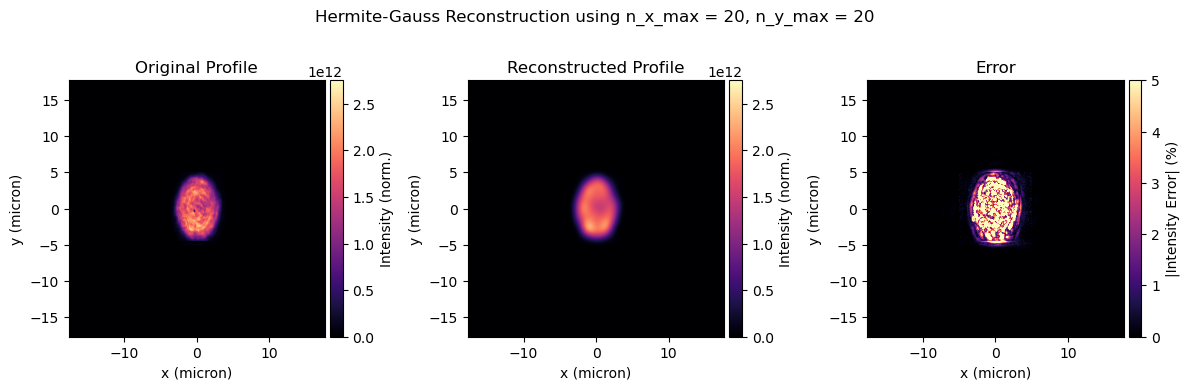

In [246]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Plotting the results
x = np.linspace(-5 * waist, 5 * waist, 500)
X, Y = np.meshgrid(x, x)

fig, ax = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)

pltextent = (np.min(x) * 1e6, np.max(x) * 1e6, np.min(x) * 1e6, np.max(x) * 1e6)
prof1 = np.abs(org_laser_profile.evaluate(X, Y, 0)) ** 2
divider0 = make_axes_locatable(ax[0])
ax0_cb = divider0.append_axes("right", size="5%", pad=0.05)
pl0 = ax[0].imshow(prof1, cmap="magma", extent=pltextent, vmin=0, vmax=np.max(prof1))
cbar0 = fig.colorbar(pl0, cax=ax0_cb)
cbar0.set_label("Intensity (norm.)")
ax[0].set_xlabel("x (micron)")
ax[0].set_ylabel("y (micron)")
ax[0].set_title("Original Profile")

prof2 = np.abs(laser_profile.evaluate(X, Y, 0)) ** 2
divider1 = make_axes_locatable(ax[1])
ax1_cb = divider1.append_axes("right", size="5%", pad=0.05)
pl1 = ax[1].imshow(prof2, cmap="magma", extent=pltextent, vmin=0, vmax=np.max(prof1))
cbar1 = fig.colorbar(pl1, cax=ax1_cb)
cbar1.set_label("Intensity (norm.)")
ax[1].set_xlabel("x (micron)")
ax[1].set_ylabel("y (micron)")
ax[1].set_title("Reconstructed Profile")


prof3 = (prof1 - prof2) / np.max(prof1)
divider2 = make_axes_locatable(ax[2])
ax2_cb = divider2.append_axes("right", size="5%", pad=0.05)
pl2 = ax[2].imshow(100 * np.abs(prof3), cmap="magma", extent=pltextent, vmin=0, vmax=5)
cbar2 = fig.colorbar(pl2, cax=ax2_cb)
cbar2.set_label("|Intensity Error| (%)")
ax[2].set_xlabel("x (micron)")
ax[2].set_ylabel("y (micron)")
ax[2].set_title("Error")

fig.suptitle(
    "Hermite-Gauss Reconstruction using n_x_max = %i, n_y_max = %i" % (n_x_max, n_y_max)
)
plt.show()

### RT

In [255]:
pulse_duration = 50e-15
spot_size = 15e-6
dimensions     = "rt"                               # Use 3D geometry
lo             = (0, -7*pulse_duration)           # Lower bounds of the simulation box
hi             = (5*spot_size, 10*pulse_duration)  # Upper bounds of the simulation box
num_points     = (300, 500)                     # Number of points in each dimension

laser_rt_org = Laser(dimensions, lo, hi, num_points, org_laser_profile)

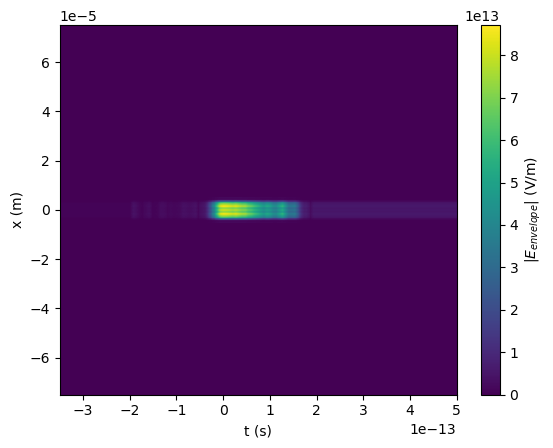

In [256]:
plt.figure()
laser_rt_org.show()

In [257]:
dimensions     = "rt"                               # Use 3D geometry
lo             = (0, -7*pulse_duration)           # Lower bounds of the simulation box
hi             = (5*spot_size, 10*pulse_duration)  # Upper bounds of the simulation box
num_points     = (300, 500)                     # Number of points in each dimension

# hack: add laser_energy attribute
laser_profile.laser_energy = energy_J

laser_rt = Laser(dimensions, lo, hi, num_points, laser_profile)

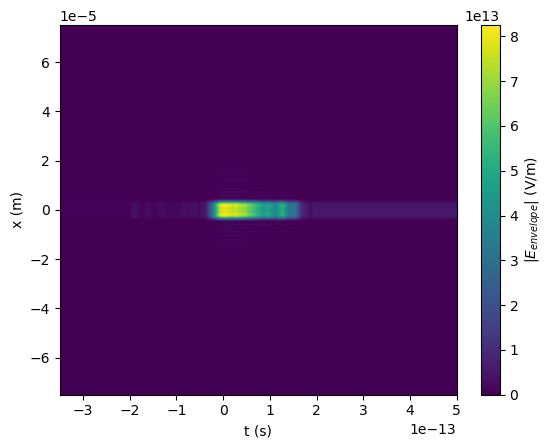

In [258]:
plt.figure()
laser_rt.show()

### XYT

In [259]:
dimensions     = "xyt"                               # Use 3D geometry
lo             = (-12.0e-6, -12.0e-6, -7*pulse_duration)           # Lower bounds of the simulation box
hi             = ( 12.0e-6,  12.0e-6, 10*pulse_duration)  # Upper bounds of the simulation box
#lo             = (transverse_x_mu[0] *mu, transverse_y_mu[0] *mu, -7*pulse_duration)           # Lower bounds of the simulation box
#hi             = (transverse_x_mu[-1]*mu, transverse_y_mu[-1]*mu, 10*pulse_duration)  # Upper bounds of the simulation box
num_points     = (300, 300, 500)                     # Number of points in each dimension
#num_points     = (50, 50, 200)                     # low res for quick tests

laser_xyt = Laser(dimensions, lo, hi, num_points, laser_profile)

KeyboardInterrupt: 

In [ ]:
plt.figure()
laser_xyt.show()

# Propagate Backwards from Focus for Initialization in Simulation

In [ ]:
profile_focal_distance = 24.0e-6
laser_xyt.propagate(-profile_focal_distance)  # Propagate the pulse upstream of the focal plane

In [ ]:
plt.figure()
laser_xyt.show()

In [ ]:
file_prefix    = "BELLAiP2_24J_24um_to_focus"

laser_xyt.write_to_file(file_prefix, file_format="h5")